In [1]:
import math

from steel_lib.si_units import si
from steelpy import aisc

from steel_lib.data_models import (
    Plate,
    ConnectionComponent,
    DesignLoads,GlobalLoads,WeldConfiguration,Plate

)
from steel_lib.connection_factory import ConnectionFactory
from steelpy.steelpy import Section
from steel_lib.materials import MATERIALS, BOLT_GRADES, WELD_ELECTRODES
from steel_lib.member_factory import MemberFactory
from steel_lib.calculations import (
    BoltShearCalculator,
    BlockShearCalculator,
    ConnectionCapacityCalculator,
    TensileYieldingCalculator,
    TensileRuptureCalculator,
    TensileYieldWhitmore,
    CompressionBucklingCalculator,
    PlateTensileYieldingCalculator,
    WebLocalYieldingCalculator,
    WebLocalCrippingCalculator,
    ShearYieldingCalculator,
    PryingActionCalculator,
    WeldCalculator,
    ConnectionAnalysis
)

In [2]:
import pandas as pd
from typing import List, Optional, Dict, Tuple, Any

def get_abs_max_from_df(df: pd.DataFrame, ignore_cols: Optional[List[str]] = None) -> Dict[str, Tuple[Any, List[Any]]]:
    """
    Calculates the absolute maximum value for columns in a DataFrame, 
    with an option to ignore a specified list of columns.

    Args:
        df (pd.DataFrame): The input DataFrame with numerical data.
        ignore_cols (Optional[List[str]], optional): A list of column headers to exclude from processing. 
                                                     If a provided column name does not exist, it's ignored.
                                                     Defaults to None, in which case all columns are processed.

    Returns:
        Dict[str, Tuple[Any, List[Any]]]: A dictionary where keys are the processed column headers
                                          and values are a tuple containing:
                                          - The absolute maximum value.
                                          - A list of index names where this value was found.
    """
    
    # Determine which columns to process by dropping the ignored ones
    if ignore_cols:
        # Find which of the provided columns to ignore actually exist in the DataFrame
        # This prevents an error if a user specifies a non-existent column
        valid_cols_to_drop = [col for col in ignore_cols if col in df.columns]
        df_to_process = df.drop(columns=valid_cols_to_drop)
    else:
        # If no columns are to be ignored, use the entire DataFrame
        df_to_process = df

    # If all columns have been dropped, return an empty dictionary
    if df_to_process.columns.empty:
        return {}
        
    # Get the absolute values of the relevant part of the DataFrame
    abs_df = df_to_process.abs()

    # Use a dictionary comprehension for an optimized, vectorized calculation
    result = {
        col: (
            abs_df[col].max(),
            abs_df.index[abs_df[col] == abs_df[col].max()].tolist()
        )
        for col in abs_df.columns
    }

    return result

def get_load(dict,key):
    return dict[key][0]
def get_governing_case(dict,key):
    return dict[key][1]


In [3]:
beam = MemberFactory.create_steelpy_member(
    section_class="W_shapes",
    section_name="W30X90",
    material="a992",
    shape_type="W",
    role="BEAM"
)

support = MemberFactory.create_steelpy_member(
    section_class="W_shapes",
    section_name="W14X176",
    material="a992",
    shape_type="W",
    role="COLUMN"
)

bracing = MemberFactory.create_steelpy_member(
    section_class="L_shapes",
    section_name="L8X6X1",
    material="a36",
    shape_type="L",
    loading_condition=2,  # Assuming this is a bracing member
    role="BRACE",
    angle=33
)

# End Plate for Column Connection
end_plate_column = MemberFactory.create_plate_member(
    thickness=1 * si.inch,
    material="a572_gr50",
    width=10 * si.inch,
    role = "END_PLATE"
)
end_plate_beam = MemberFactory.create_plate_member(
    thickness=1* si.inch,
    material="a572_gr50",
    width=10 * si.inch,
    length = beam.d + 1 * si.inch,  # Assuming the end plate length is equal to the beam depth plus some extra
    role = "END_PLATE"
)
    # Gusset Plate for Bracing Connection
gusset_plate = MemberFactory.create_plate_member(
    thickness= 0.5 * si.inch,
    material="a572_gr50",
    clipping=3/4 * si.inch,
    role="GUSSET_PLATE",
    length = 19.5 * si.inch
)


In [4]:
brace_loads = GlobalLoads(
    fx=0 * si.kip,
    fy=0 * si.kip,
    fz=0 * si.kip,
    mx=0 * si.kip * si.ft,
    my=0 * si.kip * si.ft,
    mz=0 * si.kip * si.ft,
    direct_load=250 * si.kip
)
beam_loads = GlobalLoads(
    fx=55 * si.kip,
    fy=100 * si.kip,
    fz=0 * si.kip,
    mx=0 * si.kip * si.ft,
    my=0 * si.kip * si.ft,
    mz=0 * si.kip * si.ft,
    direct_load=0 * si.kip
)

In [5]:
from steel_lib.data_models import BoltConfiguration
bolt_configuration_cg = BoltConfiguration(
    row_spacing=3.0 * si.inch,
    column_spacing=4.0 * si.inch,
    n_rows=2,
    n_columns=5,
    edge_distance_vertical=2 * si.inch,
    edge_distance_horizontal=1.25 * si.inch,
    bolt_diameter=7/8 * si.inch,
    bolt_grade="a325_x",
)
weld_configuration_bg = WeldConfiguration(weld_size=5/16*si.inch, weld_type="F", length=8*si.inch,electrode='e70xx')

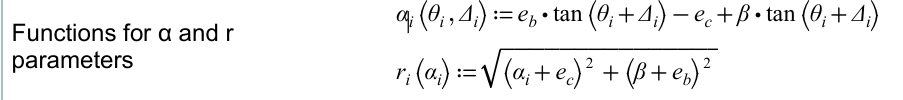

In [6]:
from handcalcs.decorator import handcalc
from math import tan,atan,sin,cos,pi
from numpy import sqrt
import pandas as pd
def ufm(beam:any,column:any,brace:any,end_plate_column:Plate,end_plate_beam:Plate,gusset_plate:Plate,bolt_configuration_cg:BoltConfiguration,weld_configuration_bg:WeldConfiguration,beam_loads:GlobalLoads,brace_loads:GlobalLoads,y_b = 1.5,sbbw = 0,Delta_theta = 5.0):
    #check inputs
    
    Delta_F_y = 0* si.kip
    Delta_theta = Delta_theta * pi/180
    N_c = bolt_configuration_cg.n_columns
    S_c = bolt_configuration_cg.column_spacing
    L_eh = bolt_configuration_cg.edge_distance_horizontal
    t_ep = end_plate_column.t
    e_c = column.d/2
    e_b = beam.d/2
    l_c = (N_c - 1) * S_c + 2 * L_eh 
    l_b = gusset_plate.length
    a_bar = gusset_plate.length/2 + sbbw + end_plate_column.t
    beta_bar = l_c/2 + y_b
    theta = brace.angle
    P_u = brace_loads.direct_load 

    # Gusset Plate Properties
    t_gp = gusset_plate.t
    F_ygp = gusset_plate.material.Fy
    F_ugp = gusset_plate.material.Fu

    # Weld Properties
    F_uw = weld_configuration_bg.electrode.Fexx
    W_size = weld_configuration_bg.weld_size
    print(W_size,F_ygp,F_ugp,t_gp)

    #Loads Beam

    F_y = beam_loads.fy
    F_x = beam_loads.fx
    @handcalc(jupyter_display=True,override="params",precision=3)
    def _initial_parameters(Delta_theta,N_c,S_c,L_eh,t_ep,e_c,e_b,l_c,a_bar,beta_bar,theta):
        
        Delta_theta = Delta_theta
        N_c = N_c
        S_c = S_c
        L_eh = L_eh
        t_ep = t_ep
        e_c = e_c
        e_b = e_b
        l_c = l_c
        a_bar = a_bar
        beta_bar = beta_bar
        theta = theta

         
    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_alpha_and_r(theta,delta_theta,e_b,e_c,beta_bar):
        theta = theta
        delta_theta = delta_theta
        a = e_b*tan(theta + delta_theta)-e_c+beta_bar*tan(theta + delta_theta)
        r = (sqrt((a+e_c)**2 + (beta_bar+e_b)**2)).to("inch")
        return a,r
    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_transfer_v(r,e_b,f_i,Delta_F_y,P_u):
        V_b_eff = (e_b*P_u)/r - f_i*Delta_F_y
        return V_b_eff
    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_weld_limit():
        k_factor_ty = 0.9
        k_factor_tr = 0.75
        k_factor_weld = 0.75

        W_limit = min(max(F_ygp,50*si.ksi)*t_gp *k_factor_ty, max(F_ugp,65*si.ksi)*t_gp *k_factor_tr) / (k_factor_weld*2*0.60*F_uw*1.5*(0.5*sqrt(2)))

        W_weld = min(W_size,W_limit)

        return W_limit,W_weld

    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_forces_bg(a,r,e_b,f_i,Delta_F_y,P_u,L_b,W_limit,W_weld):
        H_b = ((a*P_u)/r)*f_i
        V_b_eff = f_i*(e_b*P_u)/r - f_i*Delta_F_y
        M_b = V_b_eff*(a-a_bar) + f_i*Delta_F_y*(a)
        P_eq = 4*M_b/L_b
        R_peak = (sqrt(H_b**2 + (abs(V_b_eff)+abs(P_eq))**2)).to("kip")
        R_ave = (0.5* (R_peak +sqrt(H_b**2 + (abs(V_b_eff) - abs(P_eq))**2))).to("kip")
        if W_weld > W_limit: R_w = R_ave
        else: R_w = (max(R_peak,1.25*R_ave)).to("kip")
        return H_b,V_b_eff,M_b,P_eq,R_peak,R_ave,R_w

    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_forces_cg(r,f_i,Delta_F_y,P_u):
        H_c =  (P_u*e_c/r)* f_i
        V_c = (beta_bar*P_u/r)*f_i+f_i*Delta_F_y
        return H_c,V_c
    @handcalc(jupyter_display=True,override="long",precision=3)
    def _calculation_forces_bc(F_y,F_x,V_b,H_c):
        H_bc = H_c + F_x
        V_bc = V_b + F_y
        return H_bc,V_bc

    result_dict = {}
    V_b_transfer = []
    _initial_parameters(Delta_theta,N_c,S_c,L_eh,t_ep,e_c,e_b,l_c,a_bar,beta_bar,theta)
    W_limit,W_weld = _calculation_weld_limit()
    for i in range(-1,2):
        a,r = _calculation_alpha_and_r(theta,Delta_theta*i,e_b,e_c,beta_bar)
        result_dict[i] = {
            'a': a.to('inch'),
            'r': r.to('inch')
        }
        V_b_transfer.append(_calculation_transfer_v(r,e_b,1,Delta_F_y,P_u))

    

    Delta_F_y = min(V_b_transfer) -1 * si.kip
    f_i = [-1,1]
    result_final = {}
    for i in f_i:
        for case, values in result_dict.items():
            a = values['a'].to('inch')
            r = values['r'].to('inch')
            H_b,V_b_eff,M_b,P_eq,R_peak,R_ave,R_w = _calculation_forces_bg(a,r,e_b,f_i= i,Delta_F_y=Delta_F_y,P_u=P_u,L_b=l_b,W_limit=W_limit,W_weld=W_weld)
            H_c,V_c = _calculation_forces_cg(r,f_i= i,Delta_F_y=Delta_F_y,P_u=P_u)
            case_map = {-1: "θ - Δdeg", 0: "θ", 1: "θ + Δdeg"}
            orientation_map = {-1: "Compression", 1: "Tension"}

            result_final[f'Case {case_map[case]}-{orientation_map[i]}'] = {
                'a': a.to('inch'),
                'r': r.to('inch'),
                'H_b': H_b.to('kip'),
                'V_b_eff': V_b_eff.to('kip'),
                'M_b': M_b.to('kipft'),
                'P_eq': P_eq.to('kip'),
                'R_peak': R_peak.to('kip'),
                'R_ave': R_ave.to('kip'),
                'R_w': R_w.to('kip'),
                'H_c': H_c.to('kip'),
                'V_c': V_c.to('kip')
            }
    results_df = pd.DataFrame(result_final).T
    governing_loads = get_abs_max_from_df(results_df,["a","r"])
    governing_hc = get_load(governing_loads,"H_c")
    governing_vb = get_load(governing_loads,"V_b_eff")
    hc,vc = _calculation_forces_bc( F_y,F_x,governing_vb,governing_hc)
    governing_loads["H_bc"] =  (hc, get_governing_case(governing_loads,"H_c"))
    governing_loads["V_bc"] =  (vc,get_governing_case(governing_loads,"V_b_eff"))

    #create assembly
    #gusset beam connection
    gusset_beam_loads = GlobalLoads(fy = 1,fx = get_load(governing_loads,"H_b"),fx_eq = get_load(governing_loads,"P_eq"),r_w=get_load(governing_loads,"P_eq"),mx = get_load(governing_loads,"M_b"))
    gusset_beam = ConnectionFactory.create_connection(member_a=gusset_plate,member_b=beam,component_a = "along_length",component_b = "flange",global_loads=gusset_beam_loads,connection_configuration=weld_configuration_bg)
    #gusset column connection
    gusset_column_loads = GlobalLoads(fy = get_load(governing_loads,"V_c"),fx = get_load(governing_loads,"H_c"))
    endplate_gusset = ConnectionFactory.create_connection(member_a=end_plate_column,member_b=gusset_beam,component_a = "face",component_b = "width",global_loads=gusset_column_loads,connection_configuration=bolt_configuration_cg)
    column_endplate = ConnectionFactory.create_connection(member_a=column,member_b=end_plate_column,component_a = "top_flange",component_b = "face",global_loads=beam_loads,connection_configuration=bolt_configuration_cg)
    #beam column connection
    return pd.DataFrame(result_final).T,governing_loads,gusset_beam,endplate_gusset
    # _calculation_alpha_and_r(theta,Delta_theta,e_b,e_c,beta_bar)


In [7]:
# governing_loads = ufm(beam,support,bracing,end_plate_column,gusset_plate,bolt_configuration_cg,weld_configuration_bg,beam_loads,brace_loads)
# governing_loads

In [16]:
from steel_lib.core import create_all_connections_generator,create_all_connections_list_comprehension
# Parameter grids
bolt_param_grid = {
    'column_spacing': [3.0, 3.5, 4.0],
    'row_spacing': [3.0, 3.5],
    'edge_distance_vertical': [1.5, 2.0],
    'edge_distance_horizontal': [1.5, 2.0],
    'bolt_diameter': [0.75, 0.875, 1.0],
    'bolt_grade': ['a325_n', 'a325_x'],
    'n_rows': [2, 3, 4],
    'n_columns': [2],
}

aasd = create_all_connections_generator(bolt_param_grid, beam, support, beam_loads)
aasd1 = create_all_connections_generator(bolt_param_grid, beam, support, beam_loads)
aasd2 = create_all_connections_generator(bolt_param_grid, beam, support, beam_loads)

In [17]:
print(len(list(aasd)))

432


In [14]:

import itertools
all_combinations = itertools.product(
    aasd1,
    aasd2,
    aasd
)

[(1, 4, 7),
 (1, 4, 8),
 (1, 4, 9),
 (1, 5, 7),
 (1, 5, 8),
 (1, 5, 9),
 (1, 6, 7),
 (1, 6, 8),
 (1, 6, 9),
 (2, 4, 7),
 (2, 4, 8),
 (2, 4, 9),
 (2, 5, 7),
 (2, 5, 8),
 (2, 5, 9),
 (2, 6, 7),
 (2, 6, 8),
 (2, 6, 9),
 (3, 4, 7),
 (3, 4, 8),
 (3, 4, 9),
 (3, 5, 7),
 (3, 5, 8),
 (3, 5, 9),
 (3, 6, 7),
 (3, 6, 8),
 (3, 6, 9)]

In [9]:
from steel_lib.core import DesignCode
from steel_lib.calculations import aisc_360_14th
design_code = DesignCode(aisc_360_14th, debug=False)
results_list = []
for i, conn in enumerate(aasd):

    results_df, sol_latexs = design_code.check_limit_states(conn,detailed=True)
    results_list.append((results_df, sol_latexs))
results_list

[(                  name      demand    capacity       dcr       remarks details
  0  Bolt Shear Strength  28.532 kip  17.892 kip  1.594636  remarks.FAIL    None,
  [LatexConfig(main_title='Bolt Shear Calculation', sub_title={'Bolt Tensile Modified Strength Calculations': '\n\\begin{aligned}\nV_{n} &= F_{nv} \\cdot A_{bolt} \\cdot N_{shear_{planes}} \\\\&= 54.000\\ \\mathrm{ksi} \\cdot 0.442\\ \\mathrm{inch}^{2} \\cdot 1 \\\\&= 23.856\\ \\mathrm{kip}  \\\\[10pt]\n\\\\[10pt]\nV_{u} &= \\phi \\cdot V_{n} \\\\&= 0.750 \\cdot 23.856\\ \\mathrm{kip} \\\\&= 17.892\\ \\mathrm{kip}  \\\\[10pt]\n\\end{aligned}\n'})]),
 (                  name      demand    capacity      dcr       remarks details
  0  Bolt Shear Strength  19.021 kip  17.892 kip  1.06309  remarks.FAIL    None,
  [LatexConfig(main_title='Bolt Shear Calculation', sub_title={'Bolt Tensile Modified Strength Calculations': '\n\\begin{aligned}\nV_{n} &= F_{nv} \\cdot A_{bolt} \\cdot N_{shear_{planes}} \\\\&= 54.000\\ \\mathrm{ksi} \\c

In [10]:
# # It's important to keep the worker function self-contained or have it
# # work with global objects that are initialized properly.

# # Global variable to hold the design code object in each worker process
# design_code_worker = None

# def init_worker():
#     """
#     Initializer for each worker process. Creates one instance of DesignCode
#     per process, avoiding the need to pass it around.
#     """
#     print("Initializing worker process...")
#     global design_code_worker
#     from steel_lib.core import DesignCode
#     from steel_lib.calculations import aisc_360_14th
    
#     # Each process gets its own instance of the DesignCode object
#     design_code_worker = DesignCode(aisc_360_14th, debug=False)

# def check_one_connection(conn):
#     """
#     This is the "worker" function. It takes one connection and runs the
#     expensive calculation on it.
#     """
#     # The design_code_worker global is already initialized in this process
#     return design_code_worker.check_limit_states(conn)
# from multiprocessing import Pool
# import os # To get the number of CPU cores

# # The code above this line (imports, class/function definitions) remains the same.
# # Make sure to define init_worker and check_one_connection.


# if __name__ == "__main__":
#     # It's crucial to put the multiprocessing code inside this block.
    
#     # 1. Your original setup to create the 'aasd' generator/iterable
#     # (Assuming 'aasd' is the generator you created in previous steps)
#     bolt_param_grid = {
#         'column_spacing': [3.0, 3.5, 4.0],
#         'row_spacing': [3.0, 3.5],
#         'edge_distance_vertical': [1.5, 2.0],
#         'edge_distance_horizontal': [1.5, 2.0],
#         'bolt_diameter': [0.75, 0.875, 1.0],
#         'bolt_grade': ['a325_n', 'a325_x'],
#         'n_rows': [2, 3, 4],
#         'n_columns': [2],
#     }

#     aasd = create_all_connections_list_comprehension(bolt_param_grid, beam, support, beam_loads)
    
#     # 2. Determine the number of processes to use (typically all available cores)
#     num_processes = os.cpu_count()
#     print(f"Starting parallel processing with {num_processes} cores...")

#     # 3. Create the pool and run the calculations in parallel
#     with Pool(processes=num_processes, initializer=init_worker) as pool:
#         # pool.map takes the worker function and the iterable (aasd).
#         # It handles distributing the 'conn' objects and collecting results.
#         # This will be MUCH faster than the for loop.
#         all_results = pool.map(check_one_connection, aasd)

#     print("All connections processed.")

#     # 'all_results' is now a list containing the (results_df, sol_latexs)
#     # tuple for each connection. You can now process these results.
#     # for i, (results_df, sol_latexs) in enumerate(all_results):
#     #     print(f"Results for Connection {i}:")
#     #     print(results_df.head())

In [11]:


brace_gusset_connection = ConnectionFactory.create_bolted_connection(
        member_a=bracing,
        member_b=gusset_plate,
        component_a=ConnectionComponent.TOTAL,
        row_spacing=3.0 * si.inch,
        column_spacing=3.0 * si.inch,
        n_rows=2,
        n_columns=7,
        edge_distance_vertical=2 * si.inch,
        edge_distance_horizontal=1.5 * si.inch,
        bolt_diameter=7/8 * si.inch,
        bolt_grade=BOLT_GRADES["a325_x"],
        material=MATERIALS["a572_gr50"],
        angle=47.2 * math.pi / 180
    )
gusset_column_connection = ConnectionFactory.create_bolted_connection(
        member_a=gusset_plate,
        member_b=support,
        component_a=ConnectionComponent.TOTAL,
        row_spacing=3.0 * si.inch,
        column_spacing=3.0 * si.inch,
        n_rows=2,
        n_columns=7,
        edge_distance_vertical=2 * si.inch,
        edge_distance_horizontal=3 * si.inch,
        bolt_diameter=7/8 * si.inch,
        bolt_grade=BOLT_GRADES["a325_x"],
        angle=47.2 * math.pi / 180
    )
brace_gusset_tensile_yielding = TensileYieldingCalculator(endpoint=brace_gusset_connection.member_a, connection=brace_gusset_connection,load=brace_gusset_loads)
brace_gusset_tensile_yielding.check_dcr(debug=True)
brace_gusset_tensile_rupture = TensileRuptureCalculator(endpoint=brace_gusset_connection.member_a, connection=brace_gusset_connection,load=brace_gusset_loads)
brace_gusset_tensile_rupture.check_dcr(debug=True)
brace_gusset_connection_strength = ConnectionCapacityCalculator(endpoint=brace_gusset_connection.member_b, connection=brace_gusset_connection,loads=brace_gusset_loads)
brace_gusset_connection_strength.check_dcr(debug = True, number_of_shear_planes=2)
brace_gusset_block_shear = BlockShearCalculator(endpoint=brace_gusset_connection.member_a, connection=brace_gusset_connection,loads=brace_gusset_loads, loading_condition=2)
brace_gusset_block_shear.check_dcr(debug=True)


# Gusset Plate Check
gusset_plate_block_shear = BlockShearCalculator(
    endpoint=brace_gusset_connection.member_b,
    connection=brace_gusset_connection,
    loads=brace_gusset_loads,)
gusset_plate_block_shear.check_dcr(debug=True)
gusset_plate_connection_strength = ConnectionCapacityCalculator(
    endpoint=brace_gusset_connection.member_b,
    connection=brace_gusset_connection,
    loads=brace_gusset_loads,
)
gusset_plate_connection_strength.check_dcr(number_of_shear_planes = 2 , debug=True)
gusset_plate_whitmore = TensileYieldWhitmore(
    endpoint=brace_gusset_connection.member_b,
    connection=brace_gusset_connection,loads=brace_gusset_loads)
gusset_plate_whitmore.check_dcr(debug=True)
gusset_plate_compression_buckling = CompressionBucklingCalculator(
    endpoint=brace_gusset_connection.member_b,
    connection=brace_gusset_connection,loads=brace_gusset_loads)
gusset_plate_compression_buckling.calculate_capacity(debug=True)
# gusset_plate_compression_buckling.check_dcr(debug=True)


TypeError: ConnectionFactory.create_connection() missing 2 required positional arguments: 'global_loads' and 'component_b'

In [ ]:
n_columns= 6
column_spacing = 3.0 * si.inch
beam_column_connection = ConnectionFactory.create_bolted_connection(
        member_a=beam,
        member_b=end_plate_beam,
        component_a=ConnectionComponent.WEB,
        row_spacing=5.5 * si.inch,
        column_spacing=column_spacing,
        n_rows=2,
        n_columns=n_columns,
        edge_distance_vertical=2 * si.inch,
        edge_distance_horizontal=beam.d + 1 * si.inch - (n_columns -1) * column_spacing  - 3 * si.inch,
        bolt_diameter=7/8 * si.inch,
        bolt_grade=BOLT_GRADES["a490_x"],
        material=MATERIALS["a572_gr50"],
    )
initial_loads = DesignLoads(
    Pu=840 * si.kip,
    Vu=50.0 * si.kip,
    Aub=100 * si.kip
)
ufm_calculator = ConnectionAnalysis(beam = beam, support = support, endplate = end_plate_column, brace = bracing,connection=gusset_column_connection,loads=initial_loads,debug=False)
ufm_calculator.run_analysis()
interface_loads = ufm_calculator.interface_loads()
beam_column_interface_loads = interface_loads['Beam_Column_Interface']

bc_bolt_shear = BoltShearCalculator(beam_column_connection,loads=beam_column_interface_loads)
# bc_bolt_shear.calculate_capacity_fnt()
bc_bolt_shear.check_dcr_fnt(debug = False)
bc_prying_action = PryingActionCalculator(end_plate_beam,beam,beam_column_connection,loads = beam_column_interface_loads)
bc_prying_action.check_dcr()
bc_prying_action_column_flange = PryingActionCalculator(support,end_plate_beam,beam_column_connection,loads = beam_column_interface_loads)
bc_prying_action_column_flange.check_dcr()
bc_block_shear = BlockShearCalculator(endpoint=beam_column_connection.member_b, connection=beam_column_connection,loads=beam_column_interface_loads)
bc_block_shear.check_dcr(debug=False)
bc_connection_strength = ShearYieldingCalculator(endpoint=beam_column_connection.member_a, connection=beam_column_connection,loads=beam_column_interface_loads)
bc_connection_strength.check_dcr(debug=True)
bc_connection_strength = ShearYieldingCalculator(endpoint=beam_column_connection.member_a, connection=beam_column_connection,loads=beam_column_interface_loads)
bc_connection_strength.check_dcr(debug=True)


--- DEBUG: Modified Bolt Tensile Strength (Interaction) ---
  Inputs:
    Total Demand Shear Force (V)       : 319.023 kip
    Number of Bolts (n_bolts)          : 12
    Nominal Tensile Stress (Fnt)       : 113.000 ksi
    Nominal Shear Stress (Fnv)         : 84.000 ksi
    Bolt Area (Ab)                     : 0.601 inch²
    Resistance Factor (phi)            : 0.7500
  Calculations:
    Shear per Bolt (V / n_bolts)       : 26.585 kip
    Required Shear Stress (frv = V_per_bolt / Ab): 44.211 ksi
    Interaction Coefficient (Fnt / (phi * Fnv)): 1.7937
    Modified F'nt (Nominal, before cap): 67.600 ksi
  Output:
                                         --------------------
    Final Modified Tensile Stress (F'nt): 30.487 kip
--- END DEBUG: Modified Bolt Tensile Strength (Interaction) ---

--- DEBUG: Modified Bolt Tensile Strength (Interaction) ---
  Inputs:
    Total Demand Shear Force (V)       : 319.023 kip
    Number of Bolts (n_bolts)          : 12
    Nominal Tensile Stress (Fnt

0.964893805418665

In [ ]:
import handcalcs.render
import forallpeople as si
si.environment('structural')
from numpy import sqrt

In [ ]:
a = 10 * si.inch**2
a.dimensions

Dimensions(kg=0, m=2, s=0, A=0, cd=0, K=0, mol=0)

In [ ]:
%%render

a = sqrt(10 * si.inch**2)

<IPython.core.display.Latex object>

In [ ]:
from handcalcs.decorator import handcalc

# def _calculate_ufm_multipliers( beam,support,bolt_configuration,weld_configuration):
#         """Calculates and returns the load multipliers for the UFM interfaces."""
#         logger = DebugLogger("UFM Load Multipliers", debug)
        
#         beam_depth = self._get_attribute(self.beam, ["d", "depth"]).to('inch')
#         support_depth = self._get_attribute(self.support, ["d", "depth"]).to('inch')
#         edge_dist = self.config.edge_distance_horizontal
#         col_spacing = self.config.column_spacing
#         n_col = self.config.n_columns
#         angle_rad = self.config.angle

#         beam_half_depth = beam_depth / 2
#         support_half_depth = support_depth / 2
#         beta = edge_dist + ((n_col - 1) * col_spacing) / 2
#         alpha = (beam_half_depth + beta) * math.tan(angle_rad) - support_half_depth
#         r = ((alpha + support_half_depth)**2 + (beam_half_depth + beta)**2)**0.5

#         logger.add_input("Beam Depth", beam_depth)
#         logger.add_input("Support Depth", support_depth)
#         logger.add_input("Edge Distance (horiz)", edge_dist)
#         logger.add_input("Column Spacing", col_spacing)
#         logger.add_input("Number of Columns", n_col)
#         logger.add_input("Connection Angle", f"{math.degrees(angle_rad):.2f} degrees")
#         logger.add_calculation("beta", beta)
#         logger.add_calculation("alpha", alpha)
#         logger.add_calculation("r", r)

#         multipliers = LoadMultipliers(
#             vertical_force_column_interface=beta / r,
#             vertical_force_beam_interface=beam_half_depth / r,
#             horizontal_force_column_interface=support_half_depth / r,
#             horizontal_force_beam_interface=alpha / r,
#         )

#         logger.add_output("Vertical Force (Column Interface)", multipliers.vertical_force_column_interface)
#         logger.add_output("Vertical Force (Beam Interface)", multipliers.vertical_force_beam_interface)
#         logger.add_output("Horizontal Force (Column)", multipliers.horizontal_force_column_interface)
#         logger.add_output("Horizontal Force (Beam)", multipliers.horizontal_force_beam_interface)
#         logger.display()

#         return multipliers

<IPython.core.display.Latex object>

In [ ]:
b = 10 *si.kN/si.m

In [ ]:
b.to()

Available units to convert to: 
N_m
lb_ft
kip_ft


ValueError: 'Total' is not a valid ConnectionComponent

In [ ]:
from steel_lib.calculations import optional_reporting_handcalcs

@optional_reporting_handcalc(config_object = jupyter_display=False, precision=3, override="long")
def example_function(x, y):
    '''This function calculates the squares of x and y, their sum, and the ratio of the first square to the second.'''
    a = x**2 + y**2
    b = (x + y)**2
    c = a / b
    return a, b, c
example_function(3 * si.m, 4 * si.m)

ParseException: Expected == | = | \+ | \- | \* | // | / | % | , | <= | < | >= | > | != operations, found "'"  (at char 4), (line:1, col:5)

In [ ]:
def find_bolt_combinations_optimized(plate_length, possible_bolts):
    """
    Finds all possible combinations of number of bolts, spacing, and edge distance
    for a given plate length using an optimized two-loop approach.

    Args:
        plate_length: The fixed length of the plate.
        possible_bolts: A list of possible integer values for the number of bolts.

    Returns:
        A list of tuples, where each tuple contains a valid combination of
        (number of bolts, spacing, edge distance).
    """
    valid_combinations = []
    # Iterate through each possible number of bolts.
    for num_bolts in possible_bolts:
        # Special case: If there is only one bolt, the spacing term is zero.
        if num_bolts == 1:
            # 2 * edge_distance = plate_length
            if plate_length % 2 == 0:
                edge_distance = plate_length // 2
                # In this case, spacing is not part of the equation, so it's irrelevant.
                # We can add a placeholder like 'N/A' or a default value like 1.
                # Let's assume any spacing is valid and just list one representative case.
                valid_combinations.append((num_bolts, "N/A", edge_distance))
            continue # Move to the next number of bolts

        # Iterate through possible spacing values.
        # Spacing can't be so large that the length becomes negative.
        max_spacing = plate_length // (num_bolts - 1)
        for spacing in range(1, max_spacing + 1):
            # Calculate the remaining length for the two edge distances.
            remaining_length = plate_length - (num_bolts - 1) * spacing

            # Check for two conditions:
            # 1. remaining_length must be positive (edge_distance > 0).
            # 2. remaining_length must be even (so edge_distance is an integer).
            if remaining_length > 0 and remaining_length % 2 == 0:
                edge_distance = remaining_length // 2
                valid_combinations.append((num_bolts, spacing, edge_distance))
                
    return valid_combinations

# Define the fixed plate length and the possible number of bolts.
plate_length = 20
number_of_bolts_list = [1, 2, 3, 4, 5]

# Find all valid combinations using the optimized function.
solutions = find_bolt_combinations_optimized(plate_length, number_of_bolts_list)

# Print the results in a readable format.
if solutions:
    print(f"Found {len(solutions)} possible combinations for a plate length of {plate_length}:")
    print("(Number of Bolts, Spacing, Edge Distance)")
    for solution in solutions:
        print(solution)
else:
    print("No valid combinations found for the given parameters.")

In [22]:
import bisect

def find_combinations_in_range_robust(
    lower_length_bound,
    upper_length_bound,
    possible_bolts,
    possible_spacings,
    possible_edges
):
    """
    Finds all valid combinations using an optimized algorithm with binary search,
    now including robust input validation.

    Args:
        lower_length_bound: The minimum allowed length for the plate.
        upper_length_bound: The maximum allowed length for the plate.
        possible_bolts: A list of allowed integer values for the number of bolts.
        possible_spacings: A list of allowed numerical values for bolt spacing.
        possible_edges: A list of allowed numerical values for the edge distance.

    Returns:
        A list of tuples containing valid combinations and their resulting length.
    """
    # --- Step 1: Input Validation (Guard Clause) ---
    if lower_length_bound > upper_length_bound:
        print(f"Error: lower_length_bound ({lower_length_bound}) cannot be greater than upper_length_bound ({upper_length_bound}).")
        print("No solutions are possible for an invalid range.")
        return [] # Return an empty list immediately

    valid_combinations = []
    
    # --- Step 2: Pre-computation ---
    # Sort the edge distances to enable binary search.
    sorted_edges = sorted(possible_edges)

    # --- Step 3: Main Loops ---
    for n in possible_bolts:
        for s in possible_spacings:
            length_from_bolts_and_spacing = (n - 1) * s

            # --- Step 4: Algebraic Manipulation ---
            min_e_required = (lower_length_bound - length_from_bolts_and_spacing) / 2.0
            max_e_required = (upper_length_bound - length_from_bolts_and_spacing) / 2.0
            
            if not sorted_edges or max_e_required < sorted_edges[0] or min_e_required > sorted_edges[-1]:
                continue

            # --- Step 5: Binary Search ---
            start_index = bisect.bisect_left(sorted_edges, min_e_required)
            end_index = bisect.bisect_right(sorted_edges, max_e_required)

            # --- Step 6: Result Collection ---
            for i in range(start_index, end_index):
                e = sorted_edges[i]
                calculated_length = length_from_bolts_and_spacing + 2 * e
                valid_combinations.append((n, s, e, calculated_length))
                    
    return valid_combinations

# --- Your Input Parameters ---
number_of_bolts_list = [1, 2, 3, 4, 5]
spacing_list = [2, 4, 6, 8, 10, 12]
edge_distance_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# --- Example 1: The problematic input ---
print("--- Testing with invalid range (30 to 10) ---")
solutions_invalid = find_combinations_in_range_robust(
    30, 10, number_of_bolts_list, spacing_list, edge_distance_list
)
if not solutions_invalid:
    print("Function correctly returned no solutions.\n")

# --- Example 2: A valid input that will produce results ---
print("--- Testing with valid range (18 to 22) ---")
lower_allowed_length = 10
upper_allowed_length = 30
solutions_valid = find_combinations_in_range_robust(
    lower_allowed_length,
    upper_allowed_length,
    number_of_bolts_list,
    spacing_list,
    edge_distance_list
)

# Print the valid results
if solutions_valid:
    print(f"Found {len(solutions_valid)} combinations for a length between {lower_allowed_length} and {upper_allowed_length}:")
    print("(Bolts, Spacing, Edge, Resulting Length)")
    for solution in sorted(solutions_valid):
        print(solution)
else:
    print("No valid combinations found for the given parameters.")

--- Testing with invalid range (30 to 10) ---
Error: lower_length_bound (30) cannot be greater than upper_length_bound (10).
No solutions are possible for an invalid range.
Function correctly returned no solutions.

--- Testing with valid range (18 to 22) ---
Found 178 combinations for a length between 10 and 30:
(Bolts, Spacing, Edge, Resulting Length)
(1, 2, 5, 10)
(1, 2, 6, 12)
(1, 2, 7, 14)
(1, 2, 8, 16)
(1, 2, 9, 18)
(1, 2, 10, 20)
(1, 4, 5, 10)
(1, 4, 6, 12)
(1, 4, 7, 14)
(1, 4, 8, 16)
(1, 4, 9, 18)
(1, 4, 10, 20)
(1, 6, 5, 10)
(1, 6, 6, 12)
(1, 6, 7, 14)
(1, 6, 8, 16)
(1, 6, 9, 18)
(1, 6, 10, 20)
(1, 8, 5, 10)
(1, 8, 6, 12)
(1, 8, 7, 14)
(1, 8, 8, 16)
(1, 8, 9, 18)
(1, 8, 10, 20)
(1, 10, 5, 10)
(1, 10, 6, 12)
(1, 10, 7, 14)
(1, 10, 8, 16)
(1, 10, 9, 18)
(1, 10, 10, 20)
(1, 12, 5, 10)
(1, 12, 6, 12)
(1, 12, 7, 14)
(1, 12, 8, 16)
(1, 12, 9, 18)
(1, 12, 10, 20)
(2, 2, 4, 10)
(2, 2, 5, 12)
(2, 2, 6, 14)
(2, 2, 7, 16)
(2, 2, 8, 18)
(2, 2, 9, 20)
(2, 2, 10, 22)
(2, 4, 3, 10)
(2, 4, 4,